# Assignment 0

In [1]:

import pandas as pd
import numpy as np
from numpy.ma.extras import hstack
from pandas.core.reshape import concat
from scipy.spatial.distance import mahalanobis
from scipy.spatial.distance import euclidean


test_in = pd.read_csv(r"data/test_in - Copy.csv",header=None)
test_out = pd.read_csv(r"data/test_out - Copy.csv",header=None)
test_out = test_out.rename(columns={0:"label"})
train_in = pd.read_csv(r"data/train_in - Copy.csv",header=None)
train_out = pd.read_csv(r"data/train_out - Copy.csv",header=None)
train_out = train_out.rename(columns={0:"label"})
train_set = pd.concat([train_in,train_out],axis=1)
test_set = pd.concat([test_in,test_out],axis=1)


# Implementing centroid classification

In [2]:
centroids = train_set.groupby("label").mean()
results = []
digits = range(10)

x = train_in
y = train_set["label"]
c = centroids

matching_centroids = c.loc[y].set_axis(x.index)
train_in_mahalanobis = x - matching_centroids

inverse_of_cov = np.linalg.inv(train_in_mahalanobis.cov())

for _, row in test_set.iterrows():
    predicted_mahalanobis_label = None
    predicted_euclidean_label = None
    smallest_mahalanobis_distance = float("inf")
    smallest_euclidean_distance = float("inf")

    for _, cent in centroids.iterrows():
        dist_mahalanobis = mahalanobis(row.iloc[:-1], cent, inverse_of_cov)
        dist_euclidean = euclidean(row.iloc[:-1], cent)
        label = cent.name

        if dist_mahalanobis < smallest_mahalanobis_distance:
            smallest_mahalanobis_distance = dist_mahalanobis
            predicted_mahalanobis_label = label
        if dist_euclidean < smallest_euclidean_distance:
            smallest_euclidean_distance = dist_euclidean
            predicted_euclidean_label = label

    results.append({"prediction_mahalanobis": predicted_mahalanobis_label, "distance_mahalanobis": smallest_mahalanobis_distance,  "prediction_euclidean": predicted_euclidean_label, "distance_euclidean": smallest_euclidean_distance})

prediction_and_distances = pd.DataFrame(results)
test_set = pd.concat([test_set,prediction_and_distances],axis=1)


accuracy_euclidean = (test_set["label"] == test_set["prediction_euclidean"]).mean()
accuracy_mahalanobis = (test_set["label"] == test_set["prediction_mahalanobis"]).mean()
print("Euclidean accuracy:\t",accuracy_euclidean,"\nMahalanobis accuracy:",accuracy_mahalanobis)



Euclidean accuracy:	 0.804 
Mahalanobis accuracy: 0.88


# Centroid classification and accuracy using two different distance metrics

In [3]:
results_train = []

for _, row in train_set.iterrows():
    predicted_mahalanobis_label = None
    predicted_euclidean_label = None
    smallest_mahalanobis_distance = float("inf")
    smallest_euclidean_distance = float("inf")

    for _, cent in centroids.iterrows():
        dist_mahalanobis = mahalanobis(row.iloc[:-1], cent, inverse_of_cov)
        dist_euclidean = euclidean(row.iloc[:-1], cent)
        label = cent.name

        if dist_mahalanobis < smallest_mahalanobis_distance:
            smallest_mahalanobis_distance = dist_mahalanobis
            predicted_mahalanobis_label = label
        if dist_euclidean < smallest_euclidean_distance:
            smallest_euclidean_distance = dist_euclidean
            predicted_euclidean_label = label

    results_train.append({"prediction_mahalanobis": predicted_mahalanobis_label, "distance_mahalanobis": smallest_mahalanobis_distance,  "prediction_euclidean": predicted_euclidean_label, "distance_euclidean": smallest_euclidean_distance})

prediction_and_distances_train = pd.DataFrame(results_train)
train_set = pd.concat([train_set,prediction_and_distances_train],axis=1)


accuracy_euclidean_train = (train_set["label"] == train_set["prediction_euclidean"]).mean()
accuracy_mahalanobis_train = (train_set["label"] == train_set["prediction_mahalanobis"]).mean()
print("Euclidean accuracy:\t",accuracy_euclidean_train,"\nMahalanobis accuracy:",accuracy_mahalanobis_train)

Euclidean accuracy:	 0.8635032220269478 
Mahalanobis accuracy: 0.9689513766842414


# identifying harder digits to tell apart

In [4]:
from scipy.spatial.distance import cdist,pdist
from itertools import combinations

labels = combinations(digits,2)
labels = pd.DataFrame(labels)
labels = labels.rename(columns={0:"label1",1:"label2"})

centroids_distances_euclidean = pd.DataFrame(pdist(centroids,metric="euclidean"))
centroids_distances_euclidean[["label1","label2"]] = labels[["label1","label2"]]
centroids_distances_euclidean = centroids_distances_euclidean.rename(columns={0:"dist"})

centroids_distances_mahalanobis = pd.DataFrame(pdist(centroids,metric="mahalanobis",VI=inverse_of_cov))
centroids_distances_mahalanobis[["label1","label2"]] = labels[["label1","label2"]]
centroids_distances_mahalanobis = centroids_distances_mahalanobis.rename(columns={0:"dist"})


centroids_distances_mahalanobis.nsmallest(5,"dist")

,dist,label1,label2
43,5.709611,7,9
34,6.114444,4,9
33,7.025403,4,8
22,7.037856,2,8
37,7.093449,5,8


In [5]:
centroids_distances_euclidean.nsmallest(5,"dist")


,dist,label1,label2
43,5.426474,7,9
34,6.010408,4,9
25,6.118750,3,5
44,6.401166,8,9
35,6.698692,5,6


# Identifying the labels which are harder to distinguish

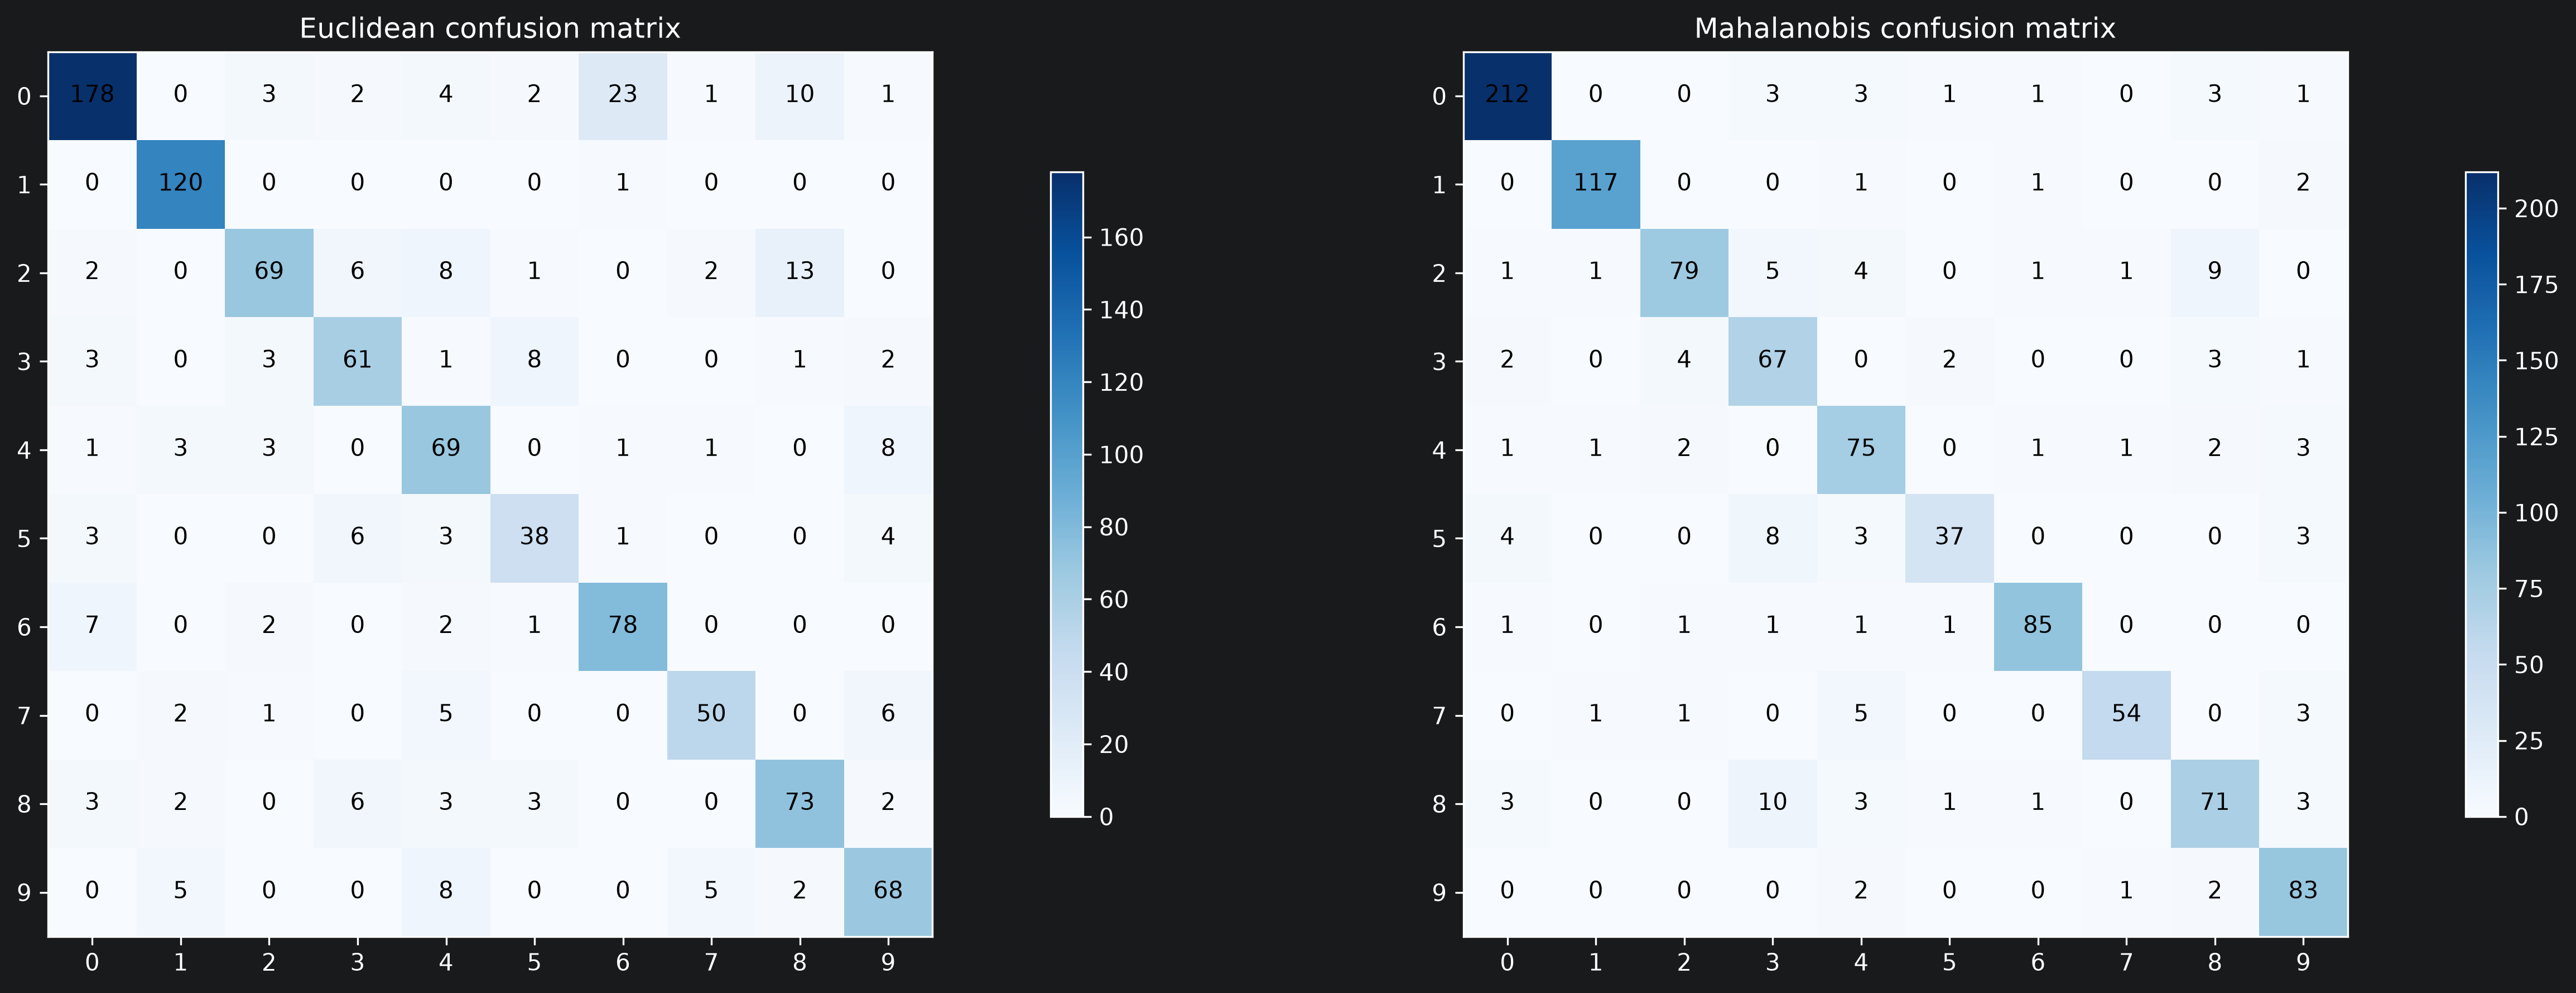

In [6]:
confusion_matrix_euclid = pd.crosstab(test_set["label"], test_set["prediction_euclidean"])
confusion_matrix_mahala = pd.crosstab(test_set["label"], test_set["prediction_mahalanobis"])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2,figsize=(20,10))

picture_euclid = axes[0].imshow(confusion_matrix_euclid,cmap=plt.cm.Blues)
axes[0].set_xticks(digits)
axes[0].set_yticks(digits)
for x in digits:
    for y in digits:
        axes[0].text(x,y,confusion_matrix_euclid.iloc[y,x],color="black",ha="center",va="center")
fig.colorbar(picture_euclid, ax=axes[0],pad=0.1,shrink=0.5)
axes[0].set_title("Euclidean confusion matrix")

picture_mahala = axes[1].imshow(confusion_matrix_mahala,cmap=plt.cm.Blues)
axes[1].set_xticks(digits)
axes[1].set_yticks(digits)
for x in digits:
    for y in digits:
        axes[1].text(x,y,confusion_matrix_mahala.iloc[y,x],color="black",ha="center",va="center")
fig.colorbar(picture_mahala, ax=axes[1],pad= 0.1,shrink=0.5)
axes[1].set_title("Mahalanobis confusion matrix")

fig.subplots_adjust(wspace=0.2)
fig.set_dpi(300)
plt.show()

# Performing PCA, T-Sne , Umap analysis on data


In [7]:
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE
test_numpy = train_in.to_numpy()

pca = PCA(n_components=2)
pca_analysis = pca.fit_transform(test_numpy)
pca_analysis = pd.DataFrame(pca_analysis).join(train_out)

umap = UMAP(n_components=2)
umap_analysis = umap.fit_transform(test_numpy)
umap_analysis = pd.DataFrame(umap_analysis).join(train_out)

tsne = TSNE(n_components=2)
tsne_analysis = tsne.fit_transform(test_numpy)
tsne_analysis = pd.DataFrame(tsne_analysis).join(train_out)





# Visualizing PCA, T-sne, UMAP

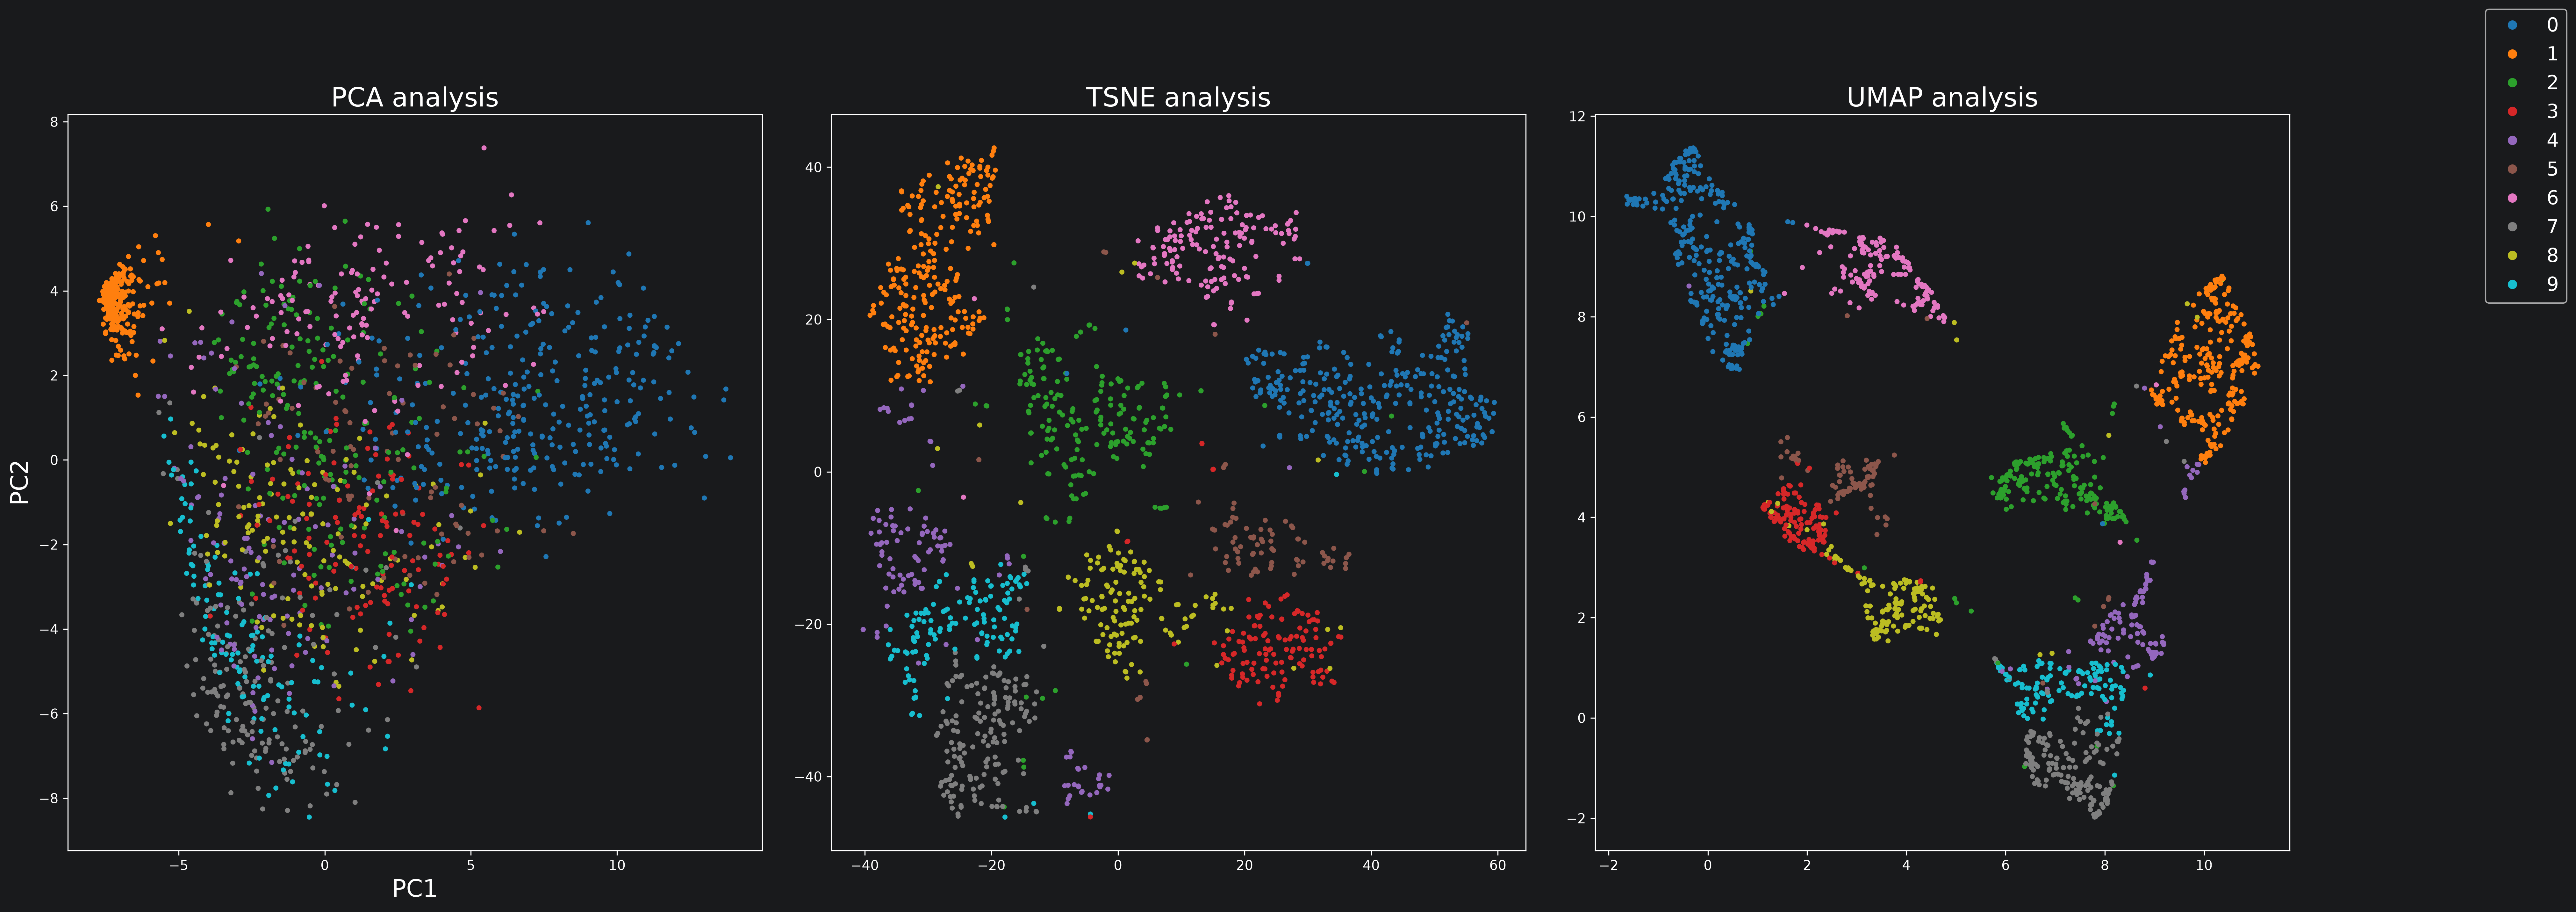

In [8]:
fig2 , axes2 = plt.subplots(1, 3,figsize=(30,10))


picture_pca = axes2[0].scatter(pca_analysis.iloc[:,0],pca_analysis.iloc[:,1],c =pca_analysis.iloc[:,2],cmap="tab10",s = 8)
axes2[0].set_title("PCA analysis",loc="center",fontsize=20)
axes2[0].set_xlabel("PC1",fontsize=18)
axes2[0].set_ylabel("PC2",fontsize=18)

axes2[1].scatter(tsne_analysis.iloc[:,0],tsne_analysis.iloc[:,1],c = tsne_analysis.iloc[:,2],cmap="tab10",s = 8)
axes2[1].set_title("TSNE analysis",loc="center",fontsize=20)


axes2[2].scatter(umap_analysis.iloc[:,0],umap_analysis.iloc[:,1],c = umap_analysis.iloc[:,2],cmap="tab10", s = 8)
axes2[2].set_title("UMAP analysis",loc="center",fontsize=20)


n = picture_pca.legend_elements()
fig2.legend(n[0],n[1],fontsize="x-large",bbox_to_anchor=(1,1))
fig2.subplots_adjust(wspace=0.1)
fig2.set_dpi(300)
plt.show()

# K-NN classification


In [9]:
from collections import Counter
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))
def mahalanobis_distance(point1,point2, inverse_of_covariance):
    diff = np.array(point1) - np.array(point2)
    return np.sqrt(diff @ inverse_of_covariance @ diff)

def knn_predict(training_data, training_labels, test_point, k, metric = "euclidean",inv_of_cov = None):
    distances = []
    if metric == "euclidean":
        for i in range(len(training_data)):
            dist = euclidean_distance(test_point, training_data[i])
            distances.append((dist, training_labels[i]))
    elif metric == "mahalanobis":
        for i in range(len(training_data)):
            dist = mahalanobis_distance(test_point, training_data[i],inverse_of_covariance = inv_of_cov)
            distances.append((dist, training_labels[i]))

    else:
        raise ValueError("Unknown metric\ncannot predict")
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]
k = 5

train_in_knn = train_in.to_numpy()
train_out_knn = train_out.to_numpy().ravel()
predictions = [knn_predict(train_in_knn, train_out_knn, point, k)
               for point in test_in.to_numpy()]



# K-NN with Euclidean as distance matrix

In [10]:
predictions_train = [knn_predict(train_in_knn, train_out_knn, point, k)
               for point in train_in.to_numpy()]
predictions = [knn_predict(train_in_knn, train_out_knn, point, k)
               for point in test_in.to_numpy()]

# K-NN with Mahalanobis as distance metric

In [11]:
inverse_of_cov_knn = np.linalg.inv(train_in_mahalanobis.cov() + (np.identity(train_in_mahalanobis.cov().shape[0])*9))
predictions_mahalanobis_train = [knn_predict(train_in_knn, train_out_knn , point, k, metric = "mahalanobis", inv_of_cov = inverse_of_cov_knn) for point in train_in.to_numpy()]
predictions_mahalanobis = [knn_predict(train_in_knn, train_out_knn , point, k, metric = "mahalanobis", inv_of_cov = inverse_of_cov_knn) for point in test_in.to_numpy()]

# Checking the accuracy

In [12]:
acc_knn = np.mean(np.array(predictions_train) == train_out["label"].to_numpy())
print("kNN accuracy(euclidean) on training set:", acc_knn)
acc_knn_mahalanobis = np.mean(np.array(predictions_mahalanobis_train) == train_out["label"].to_numpy())
print("kNN accuracy(mahalanobis) on training set:", acc_knn_mahalanobis)
print("-"*10)
acc_knn_test = np.mean(np.array(predictions) == test_out["label"].to_numpy())
print("kNN accuracy(euclidean) on test set:", acc_knn_test)
acc_knn_mahalanobis_test = np.mean(np.array(predictions_mahalanobis) == test_out["label"].to_numpy())
print("kNN accuracy(mahalanobis) on test set:", acc_knn_mahalanobis_test)

kNN accuracy(euclidean) on training set: 0.9730521382542472
kNN accuracy(mahalanobis) on training set: 0.9724663151728178
----------
kNN accuracy(euclidean) on test set: 0.913
kNN accuracy(mahalanobis) on test set: 0.91


# Confusion matrix

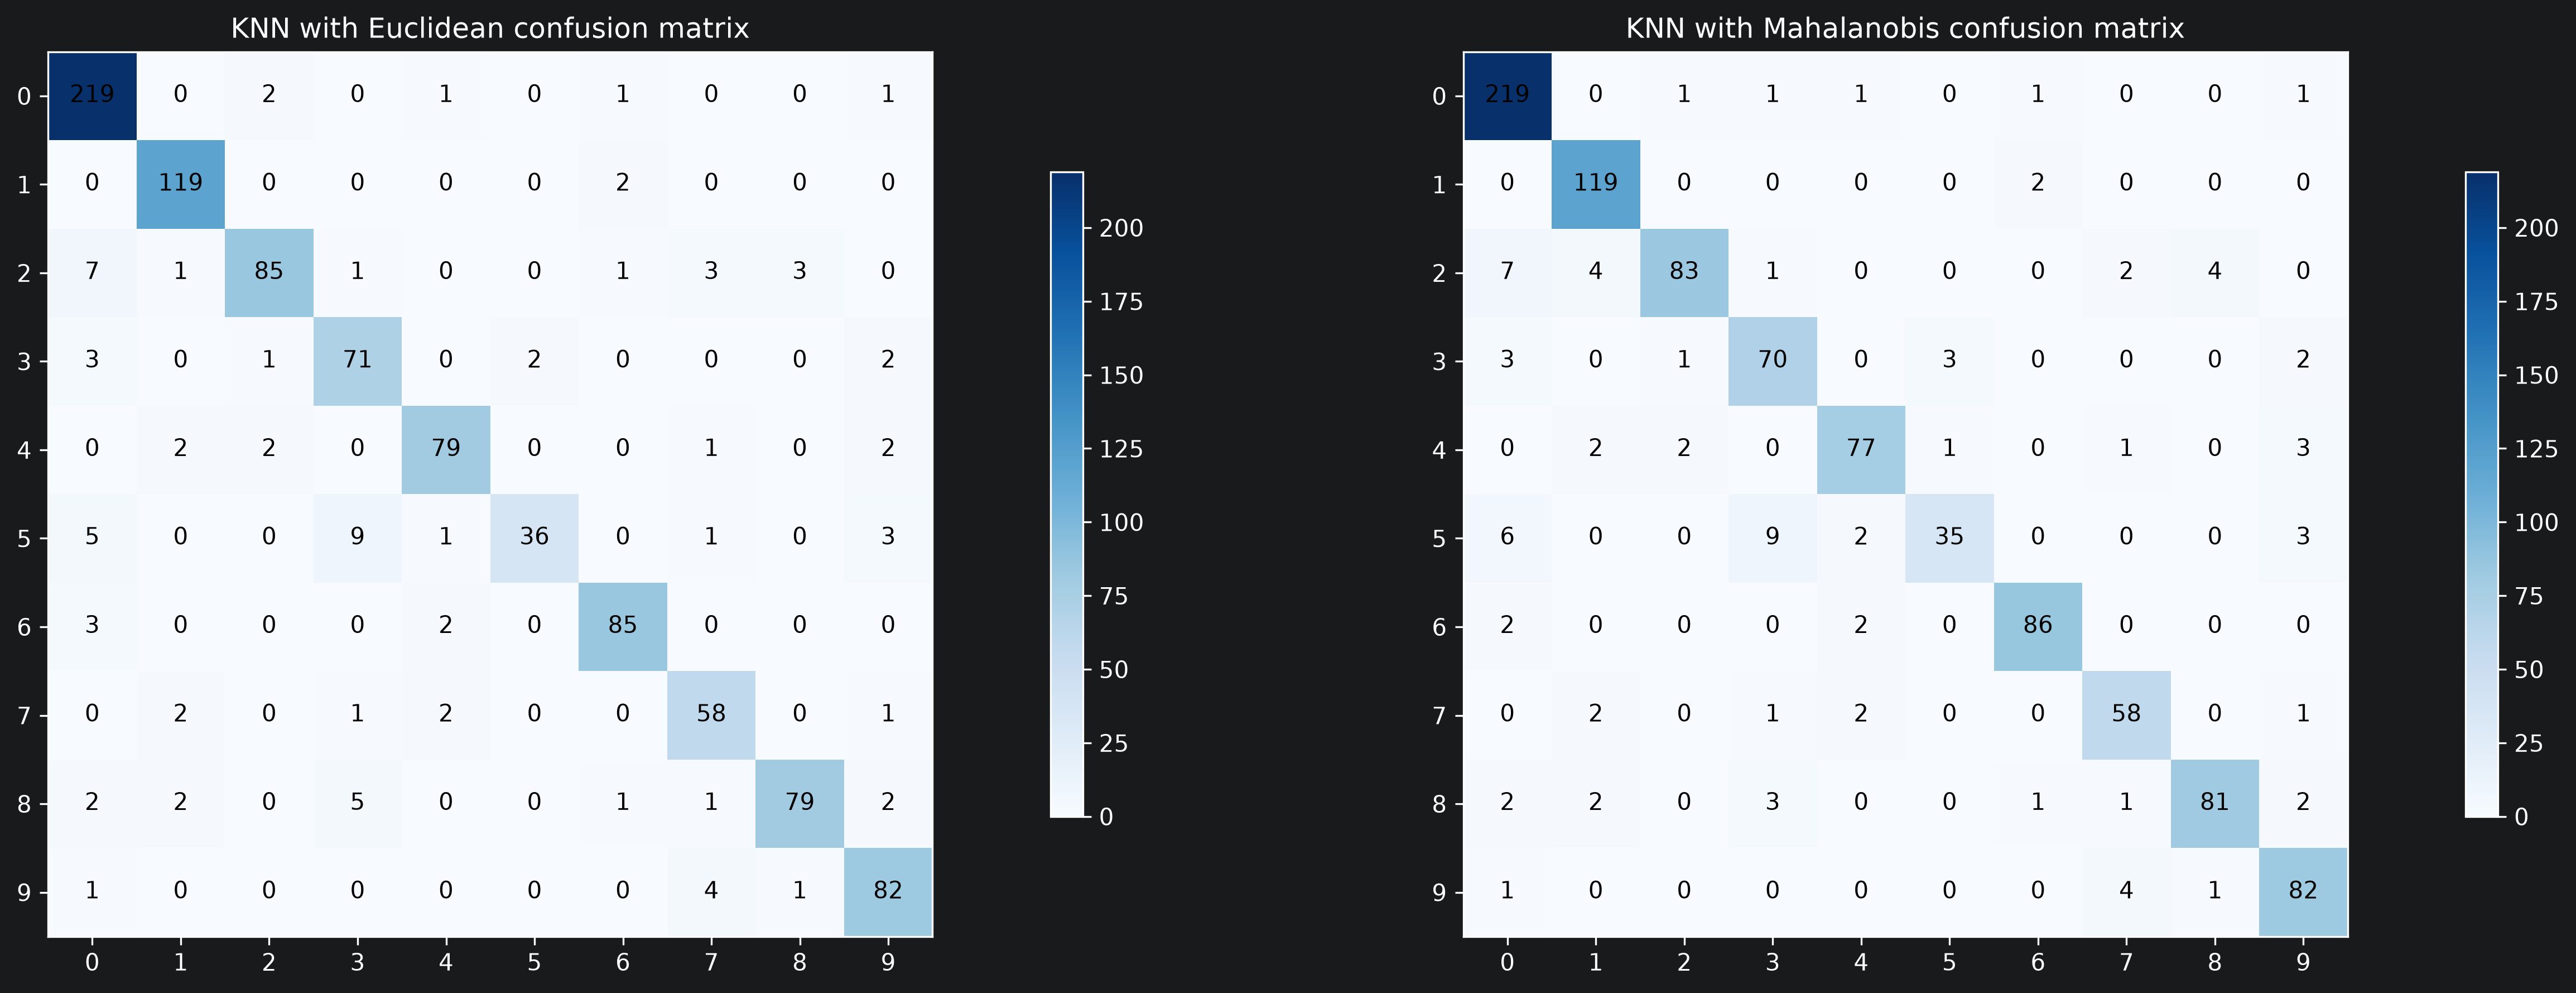

In [13]:
confusion_matrix_euclid_knn = pd.crosstab(test_set["label"], pd.Series(predictions))
confusion_matrix_mahala_knn = pd.crosstab(test_set["label"], pd.Series(predictions_mahalanobis))


fig3, axes3 = plt.subplots(1, 2,figsize=(20,10))

picture_euclid_knn = axes3[0].imshow(confusion_matrix_euclid_knn,cmap=plt.cm.Blues)
axes3[0].set_xticks(digits)
axes3[0].set_yticks(digits)
for x in digits:
    for y in digits:
        axes3[0].text(x,y,confusion_matrix_euclid_knn.iloc[y,x],color="black",ha="center",va="center")
fig3.colorbar(picture_euclid_knn, ax=axes3[0],pad=0.1,shrink=0.5)
axes3[0].set_title("KNN with Euclidean confusion matrix")

picture_mahala_knn = axes3[1].imshow(confusion_matrix_mahala_knn,cmap=plt.cm.Blues)
axes3[1].set_xticks(digits)
axes3[1].set_yticks(digits)
for x in digits:
    for y in digits:
        axes3[1].text(x,y,confusion_matrix_mahala_knn.iloc[y,x],color="black",ha="center",va="center")
fig3.colorbar(picture_mahala_knn, ax=axes3[1],pad= 0.1,shrink=0.5)
axes3[1].set_title("KNN with Mahalanobis confusion matrix")

fig3.subplots_adjust(wspace=0.2)
fig3.set_dpi(300)
plt.show()

In [14]:
from sklearn.preprocessing import OneHotEncoder


def ReLU(x):
     return np.maximum(0, x)

def Softmax(x):
    shifted = x - np.max(x)
    return np.exp(shifted) / np.sum(np.exp(shifted))


# Task 2.1


In [15]:
def Training(training_data, training_labels, test_data, test_labels, epoch = 100, random_seed = 42, learning_rate = 0.001):
    nn_hidden_layers = 10
    np.random.seed(random_seed)
    training_data = training_data.to_numpy()
    # adding bias to the training data to fit everything instead of having a separate array for bias
    X = np.hstack([training_data, np.ones((training_data.shape[0],1))])
    encoder = OneHotEncoder(sparse_output=False)
    # Making oneHot encoded array of labels
    T = encoder.fit_transform(training_labels.to_numpy().reshape(-1, 1))
    y_train = np.argmax(T, axis=1)
    W = np.random.randn(X.shape[1],nn_hidden_layers) * np.sqrt(2/training_data.shape[1])
    accuracies = []
    losses = []
    X_test = np.hstack([test_data, np.ones((test_data.shape[0],1))])
    y_test = test_labels.to_numpy().ravel().astype(int)
    T_test = np.eye(10)[y_test]
    test_accuracies = []
    test_losses = []
    for e in range(epoch):
        A = X @ W
        Y = np.where(A>0 , 1 , 0)

        A_test = X_test @ W
        Y_test = np.where(A_test > 0, 1, 0)
        test_accuracies.append(np.mean(np.argmax(A_test, axis=1) == y_test))
        test_losses.append(np.mean((T_test - Y_test) ** 2))
        accuracies.append(np.mean(np.argmax(A, axis=1) == y_train))
        losses.append(np.mean((T - Y) ** 2))
        W += learning_rate * X.T @ (T - Y)

        print(f"epoch {e+1:3d}/{epoch}  loss {losses[-1]:.4f}  acc {accuracies[-1]:.4f}  "
              f"test acc {test_accuracies[-1]:.4f}", end="\r", flush=True)

    print()
    return W, losses, accuracies, test_losses, test_accuracies







# Testing differen hyperparameters

In [16]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 88, learning_rate = 0.001);

epoch 100/100  loss 0.0066  acc 0.9795  test acc 0.8890


In [17]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 42, learning_rate = 0.001);

epoch 100/100  loss 0.0082  acc 0.9783  test acc 0.8820


In [18]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 518, learning_rate = 0.001);

epoch 100/100  loss 0.0093  acc 0.9619  test acc 0.8700


In [19]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 2251, learning_rate = 0.001);

epoch 100/100  loss 0.0091  acc 0.9725  test acc 0.8820


In [20]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 221, learning_rate = 0.001);

epoch 100/100  loss 0.0068  acc 0.9777  test acc 0.8900


In [21]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 188, learning_rate = 0.001);

epoch 100/100  loss 0.0087  acc 0.9754  test acc 0.8940


# Task 3

In [22]:
import numpy as np

XOR_in = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=float)

XOR_out = np.array([0, 1, 1, 0], dtype=float)


def sigmoid(z):
    # 1 / (1 + e^-z), works element-wise on an array.
    return 1 / (1 + np.exp(-z))


class XorTrainer:


    def __init__(self, learning_rate=0.5, init="uniform", init_scale=1.0, random_seed=None):
        self.learning_rate = learning_rate
        self.init = init
        self.init_scale = init_scale
        self.random_seed = random_seed
        self.history = {"mse": [], "misclassified": []}
        self.initialize_weights()

    #  weights

    def initialize_weights(self):

        if self.random_seed is not None:
            np.random.seed(self.random_seed)

        s = self.init_scale
        if self.init == "uniform":
            self.W1 = np.random.uniform(-s, s, (2, 2))
            self.c = np.random.uniform(-s, s, 2)
            self.W2 = np.random.uniform(-s, s, 2)
            self.b = np.random.uniform(-s, s)
        elif self.init == "normal":
            self.W1 = np.random.randn(2, 2) * s
            self.c = np.random.randn(2) * s
            self.W2 = np.random.randn(2) * s
            self.b = np.random.randn() * s
        else:
            raise ValueError(f"Unknown init strategy: {self.init}")

    # forward

    def forward(self, X):

        z1 = X @ self.W1.T + self.c
        a1 = sigmoid(z1)
        z2 = a1 @ self.W2 + self.b
        y = sigmoid(z2)
        return y, a1

    # loss

    def mse(self, y, t):
        """Mean squared error"""
        return np.mean((y - t) ** 2)

    def misclassified(self, y, t):
        """How many of the inputs lead to wrong predictions"""
        return int(np.sum(np.round(y) != t))

    #  backward

    def gradients(self, X, a1, y, t):
        """Return grad_W1, grad_c, grad_w2, grad_b."""
        d2 = 2 * (y - t) * y * (1 - y) / len(t)
        grad_b = np.sum(d2)
        grad_w2 = a1.T @ d2
        d1 = np.outer(d2, self.W2) * a1 * (1 - a1)
        grad_c = np.sum(d1, axis=0)
        grad_W1 = d1.T @ X
        return grad_W1, grad_c, grad_w2, grad_b

    #  training

    def train(self, X=XOR_in, T=XOR_out, iterations=5000, verbose=True):
        """Gradient descent: forward, record, gradients, update. Repeat.

        """
        for e in range(iterations):
            y, a1 = self.forward(X)

            loss = self.mse(y, T)
            wrong = self.misclassified(y, T)
            self.history["mse"].append(loss)
            self.history["misclassified"].append(wrong)

            if verbose and e % 50 == 0:
                print(f"iter {e:5d}   mse {loss:.4f}   misclassified {wrong}", end = "\r")

            grad_W1, grad_c, grad_W2, grad_b = self.gradients(X, a1, y, T)
            self.W1 -= self.learning_rate * grad_W1
            self.W2 -= self.learning_rate * grad_W2
            self.c -= self.learning_rate * grad_c
            self.b -= self.learning_rate * grad_b

        return self

    # inference

    def predict(self, X=XOR_in):
        """Return the 4 raw outputs (between 0 and 1)."""
        y, _ = self.forward(X)
        return y

    def classify(self, X=XOR_in):
        """Return the 4 outputs thresholded at 0.5, as 0s and 1s."""
        return np.round(self.predict(X))

    def evaluate(self, X=XOR_in, T=XOR_out):
        """Return (mse, misclassified, solved) for the current weights.

        solved is True when all 4 inputs are classified correctly.
        """
        y = self.predict(X)
        wrong = self.misclassified(y, T)
        return self.mse(y, T), wrong, wrong == 0


def lazy_search(max_tries=1_000_000, **kwargs):
    """Keep drawing random weights until the network happens to compute XOR.

    No training at all: initialize, evaluate, repeat.
    Return the number of tries needed (or None if max_tries is reached).
    """
    # TODO
    pass

# The learned weights lead the solution to local minimum
net = XorTrainer(learning_rate=0.5, init="uniform", init_scale=1.0, random_seed=518)
net.train(XOR_in, XOR_out, iterations=5000)
print("\n",net.evaluate())
print(net.classify())

iter  4950   mse 0.1277   misclassified 2
 (np.float64(0.12768542130975935), 2, False)
[0. 0. 1. 1.]


In [23]:
# this seed seems to solve the problem at exactly 3500th iteration
net2 = XorTrainer(learning_rate=0.5, init="uniform", init_scale=1.0, random_seed=254)
net2.train(XOR_in, XOR_out, iterations=3501)
print("\n",net2.evaluate())
print(net2.classify())

iter  3500   mse 0.1059   misclassified 0
 (np.float64(0.10565112701323344), 0, True)
[0. 1. 1. 0.]


In [24]:
net3 = XorTrainer(learning_rate=0.5, init="uniform", init_scale=2.0, random_seed=42)
net3.train(XOR_in, XOR_out, iterations=3501)
print("\n",net3.evaluate())
print(net3.classify())

iter  3500   mse 0.0032   misclassified 0
 (np.float64(0.003159554382422817), 0, True)
[0. 1. 1. 0.]


In [25]:
net4 = XorTrainer(learning_rate=0.5, init="normal", init_scale=2.0, random_seed=50)
net4.train(XOR_in, XOR_out, iterations=3501)
print("\n",net4.evaluate())
print(net4.classify())

iter  3500   mse 0.0028   misclassified 0
 (np.float64(0.002779781858850413), 0, True)
[0. 1. 1. 0.]
